<a href="https://colab.research.google.com/github/OnwutaKelvin/ML-notebooks/blob/main/ESC_12_Pavement_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier, ExtraTreesClassifier, BaggingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression, RidgeClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings('ignore')

In [ ]:
df = pd.read_csv('/content/ESC 12 Pavement Dataset.csv')
df.head()

,Segment ID,PCI,Road Type,AADT,Asphalt Type,Last Maintenance,Average Rainfall,Rutting,IRI,Needs Maintenance
0,SID 155440,70.00,Secondary,4634,Concrete,2022,42.07,15.11,0.68,0
1,SID 244365,37.87,Tertiary,3474,Asphalt,2017,79.60,19.67,0.99,1
2,SID 137867,88.32,Tertiary,1734,Concrete,2019,62.69,14.73,0.50,0
3,SID 540519,52.30,Tertiary,3119,Asphalt,2008,79.32,17.01,1.04,1
4,SID 745776,49.10,Tertiary,3505,Asphalt,2019,71.81,21.08,1.18,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1050000 entries, 0 to 1049999
Data columns (total 10 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   Segment ID         1050000 non-null  object 
 1   PCI                1050000 non-null  float64
 2   Road Type          1050000 non-null  object 
 3   AADT               1050000 non-null  int64  
 4   Asphalt Type       1050000 non-null  object 
 5   Last Maintenance   1050000 non-null  int64  
 6   Average Rainfall   1050000 non-null  float64
 7   Rutting            1050000 non-null  float64
 8   IRI                1050000 non-null  float64
 9   Needs Maintenance  1050000 non-null  int64  
dtypes: float64(4), int64(3), object(3)
memory usage: 80.1+ MB


In [ ]:
df.describe()

,PCI,AADT,Last Maintenance,Average Rainfall,Rutting,IRI,Needs Maintenance
count,1.050000e+06,1.050000e+06,1.050000e+06,1.050000e+06,1.050000e+06,1.050000e+06,1.050000e+06
mean,5.470744e+01,1.155683e+04,2.018147e+03,6.498192e+01,1.659194e+01,8.500802e-01,4.998752e-01
std,2.877674e+01,1.389092e+04,4.984028e+00,1.802855e+01,2.891353e+00,2.366776e-01,5.000002e-01
min,0.000000e+00,-1.931300e+04,1.959000e+03,0.000000e+00,7.220000e+00,-2.800000e-01,0.000000e+00
25%,2.998000e+01,2.288000e+03,2.017000e+03,4.996000e+01,1.400000e+01,6.900000e-01,0.000000e+00
50%,5.502000e+01,5.307000e+03,2.019000e+03,6.497000e+01,1.703000e+01,8.500000e-01,0.000000e+00
75%,8.007000e+01,1.644100e+04,2.021000e+03,8.003000e+01,1.920000e+01,1.010000e+00,1.000000e+00
max,1.000000e+02,2.001500e+05,2.028000e+03,1.298400e+02,2.409000e+01,1.910000e+00,1.000000e+00


In [ ]:
df.shape

(1050000, 10)

Analysis of numerical features

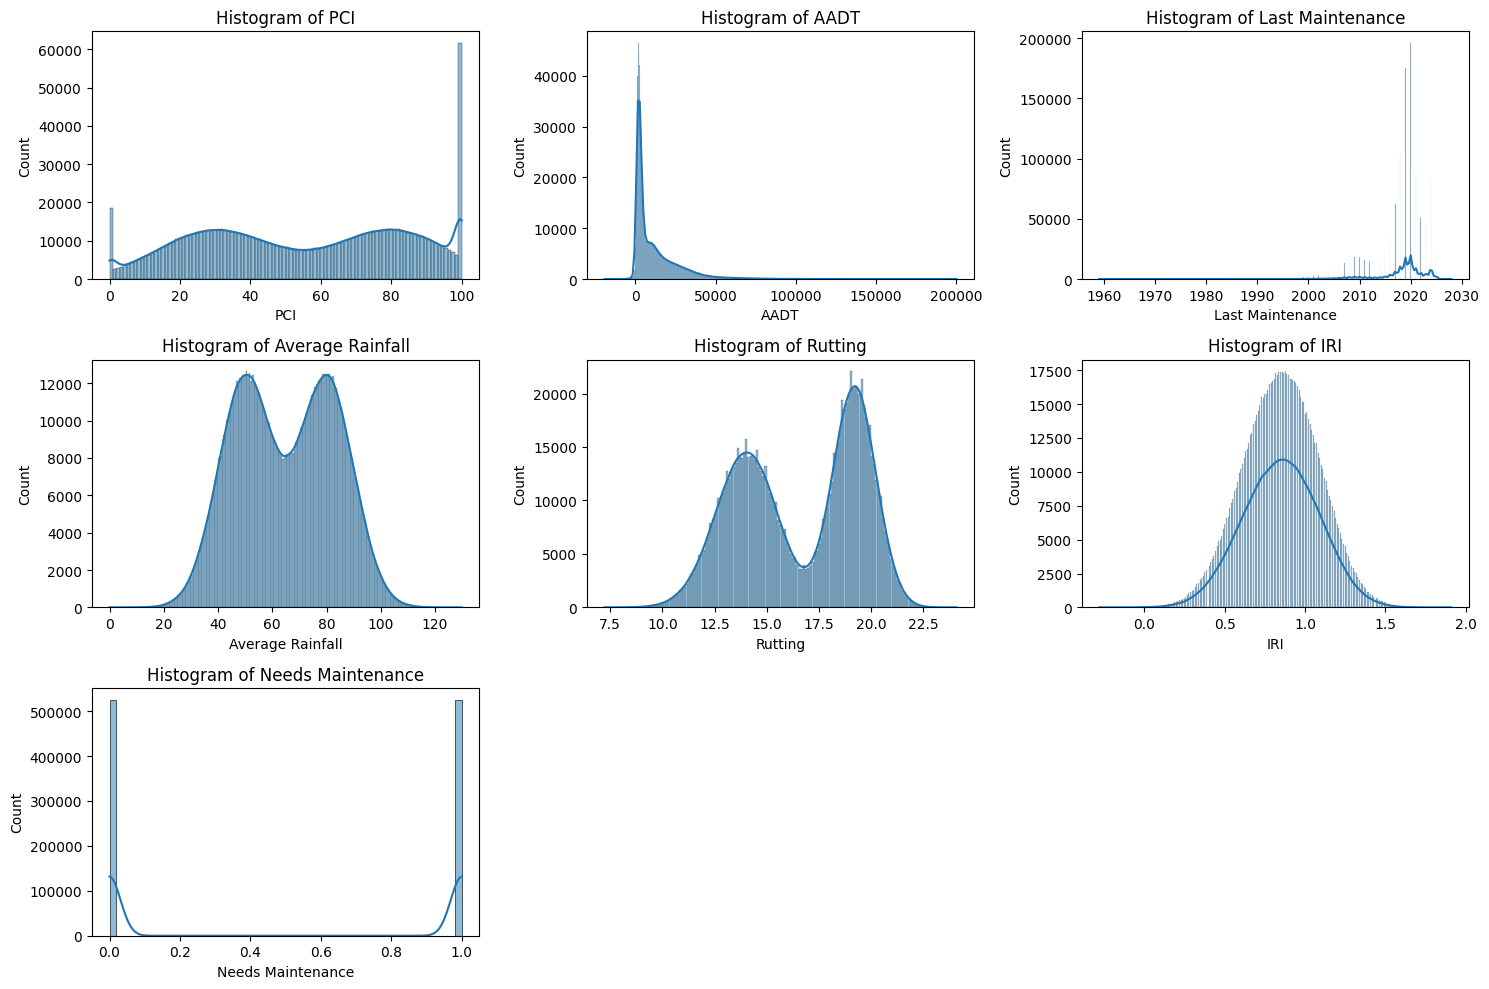

In [ ]:
numeric_df = df.select_dtypes(include=[np.number])
numeric_cols = numeric_df.columns
plt.figure(figsize=(15, 10))
for i , col in enumerate(numeric_cols):
  plt.subplot(3, 3, i+1)
  sns.histplot(numeric_df[col], kde=True)
  plt.title(f'Histogram of {col}')
plt.tight_layout()
plt.show()

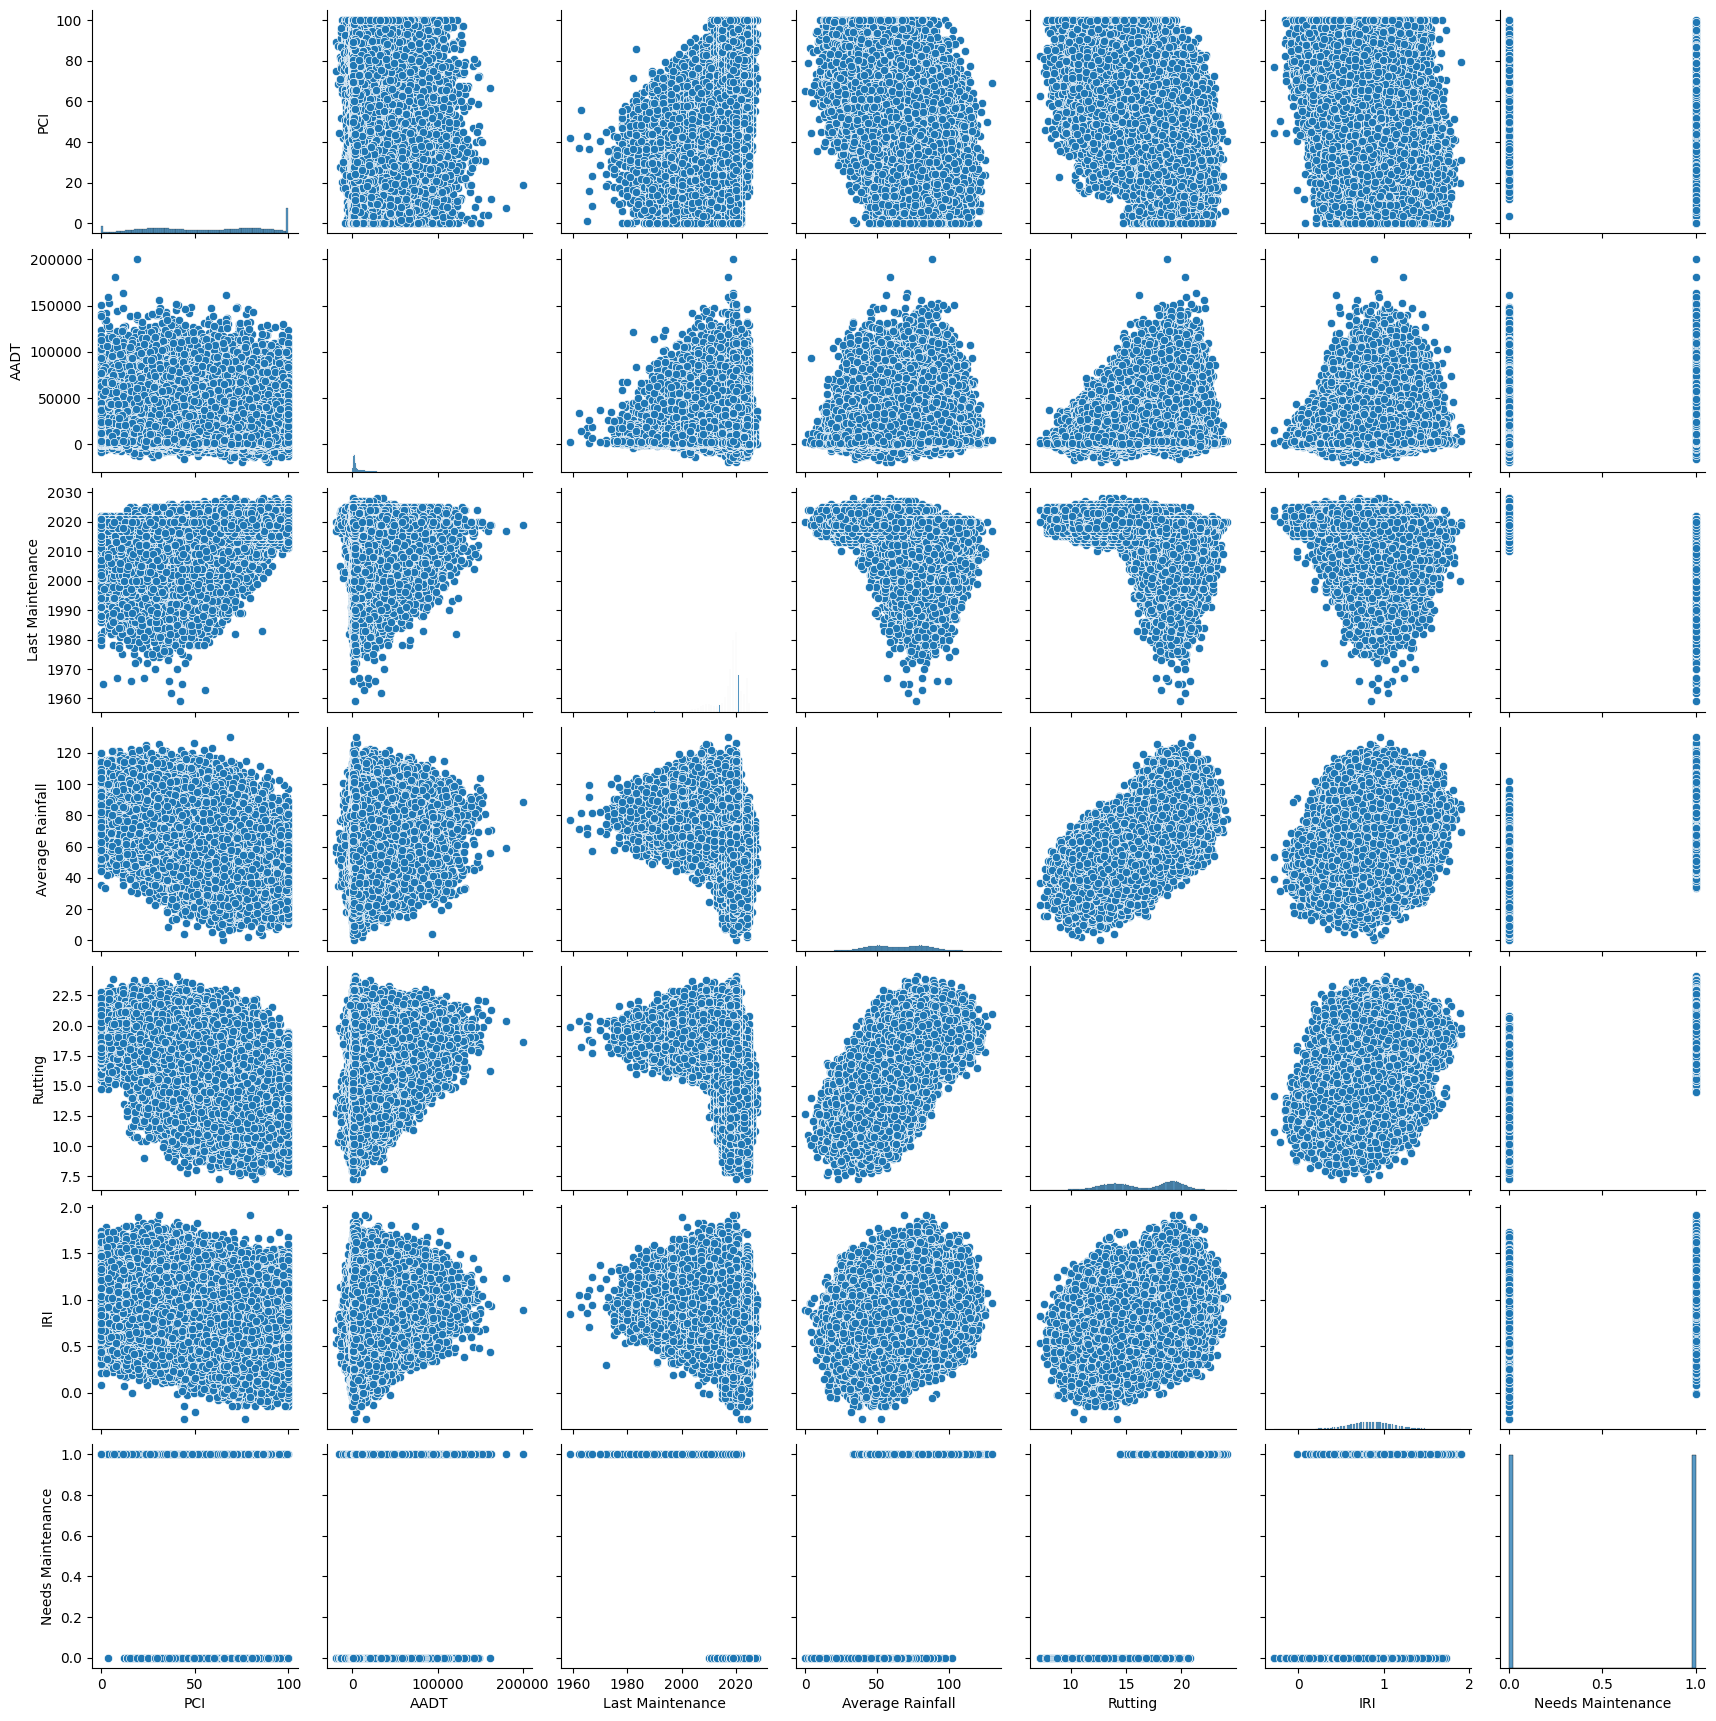

In [ ]:
sns.pairplot(numeric_df)
plt.show()

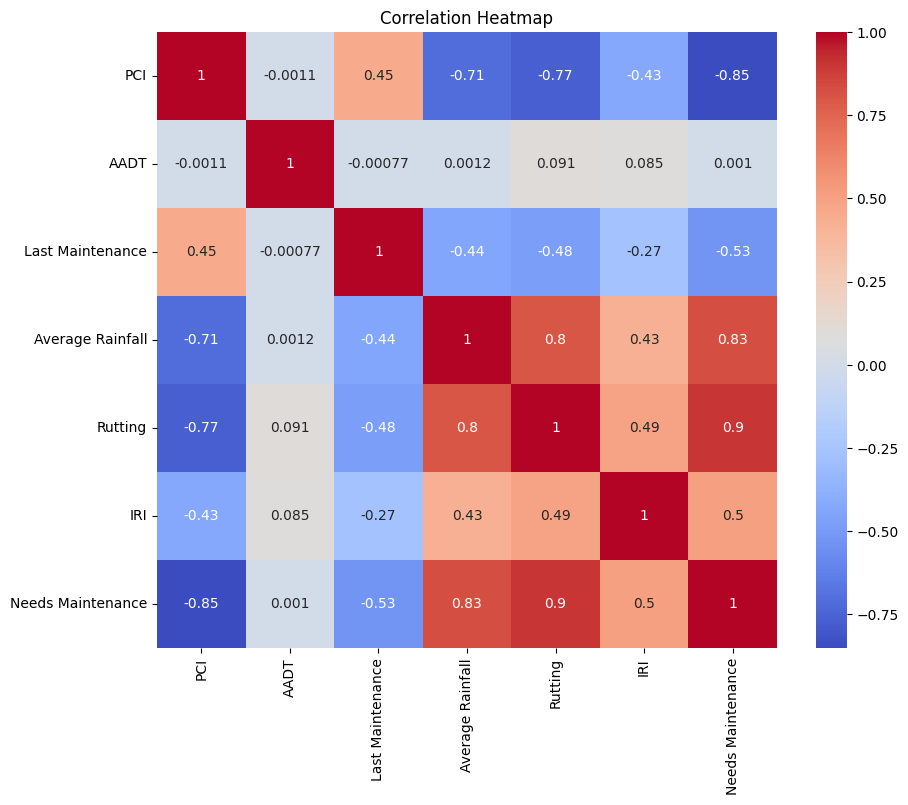

In [ ]:
if len(numeric_df.columns) >= 4:
  plt.figure(figsize=(10, 8))
  corr = numeric_df.corr()
  sns.heatmap(corr, annot=True, cmap='coolwarm')
  plt.title('Correlation Heatmap')
  plt.show()

Distribution of Road Types

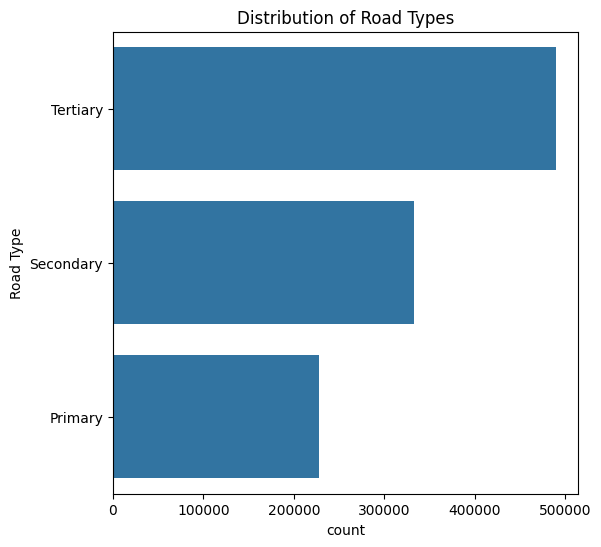

In [ ]:
plt.figure(figsize=(6, 6))
road_type_counts = df['Road Type'].value_counts()
sns.countplot(y = 'Road Type', data=df, order = road_type_counts.index)
plt.title('Distribution of Road Types')
plt.show()

Distribution of Asphalt Types

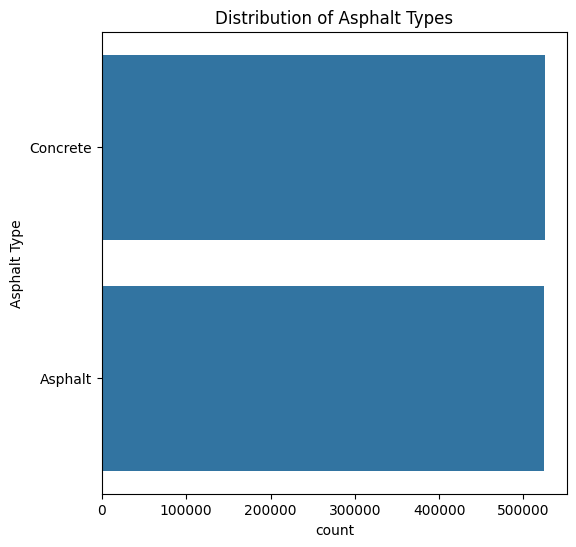

In [ ]:
plt.figure(figsize=(6, 6))
asphalt_counts = df['Asphalt Type'].value_counts()
sns.countplot(y = 'Asphalt Type', data=df, order= asphalt_counts.index)
plt.title('Distribution of Asphalt Types')
plt.show()

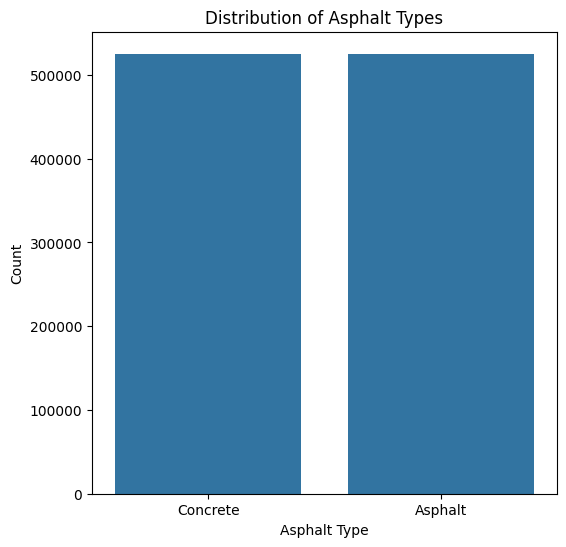

In [ ]:
plt.figure(figsize=(6, 6))
asphalt_counts = df['Asphalt Type'].value_counts()
sns.barplot(x = asphalt_counts.index, y = asphalt_counts.values)
plt.title('Distribution of Asphalt Types')
plt.ylabel('Count')
plt.xlabel('Asphalt Type')
plt.show()

Feature Selection

In [ ]:
feature_col = ['PCI', 'Road Type', 'AADT', 'Asphalt Type', 'Last Maintenance', 'Average Rainfall', 'Rutting', 'IRI']
X = df[feature_col]
y = df['Needs Maintenance']

In [ ]:
y.value_counts()

,count
Needs Maintenance,
0,525131
1,524869


Data processing and Encoding


In [ ]:
preprocessor = ColumnTransformer(
    transformers=[
        ('cat', OneHotEncoder(drop='first'), ['Road Type', 'Asphalt Type'])
    ],
    remainder='passthrough'
)
x_encoded = preprocessor.fit_transform(X)
X_train, X_test, y_train, y_test = train_test_split(x_encoded, y, test_size=0.2, random_state=42)

Model Training and Evaluation

In [ ]:
model = {
    'Random Forest': RandomForestClassifier(n_jobs=-1),
    'Decision Tree': DecisionTreeClassifier(),
    'K-Nearest Neighbors': KNeighborsClassifier(n_jobs=-1),
    'Logistic Regression': LogisticRegression(n_jobs=-1, max_iter=1000),
    'Gradient Boosting': GradientBoostingClassifier(),
    'AdaBoost': AdaBoostClassifier(),
    'Naive Bayes': GaussianNB(),
    'Extra Trees': ExtraTreesClassifier(n_jobs=-1),
    'Bagging': BaggingClassifier(),
    'Ridge': RidgeClassifier(),
}

result = {}
for name, clf in model.items():
  clf.fit(X_train, y_train)
  y_pred = clf.predict(X_test)
  accuracy = accuracy_score(y_test, y_pred)
  cv_scores = cross_val_score(clf, x_encoded, y, cv=5)

  result[name] = {
      'Accuracy Score': accuracy,
      'Cross Validation Score': cv_scores.mean(),
      'Cross Validation STD': np.std(cv_scores),
      'Classification Report': classification_report(y_test, y_pred),
      'Confusion Matrix': confusion_matrix(y_test, y_pred),
      }
  print(f"Trained {name}")

Trained Random Forest
Trained Decision Tree
Trained K-Nearest Neighbors
Trained Logistic Regression
Trained Gradient Boosting
Trained AdaBoost
Trained Naive Bayes
Trained Extra Trees
Trained Bagging
Trained Ridge


Visualizing Confusion matrices

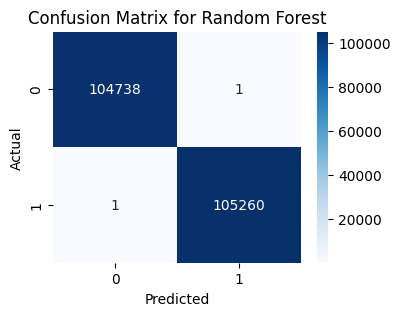

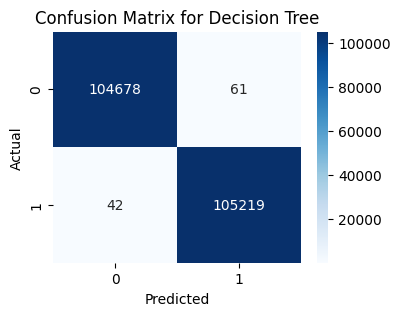

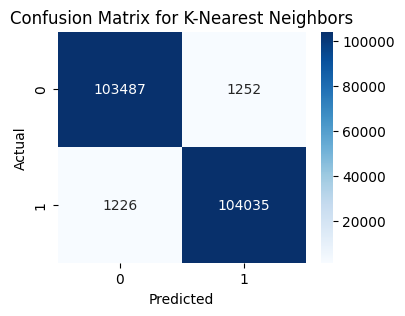

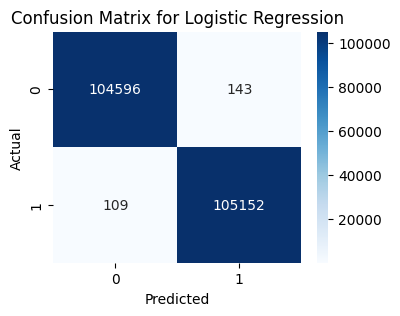

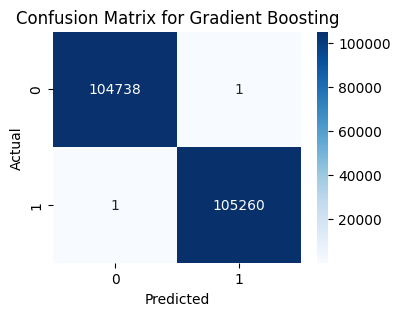

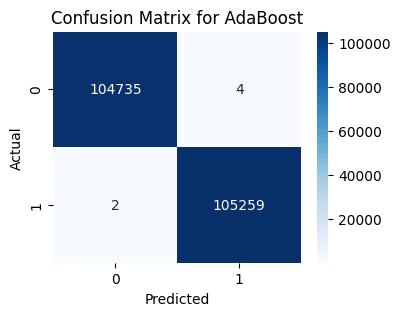

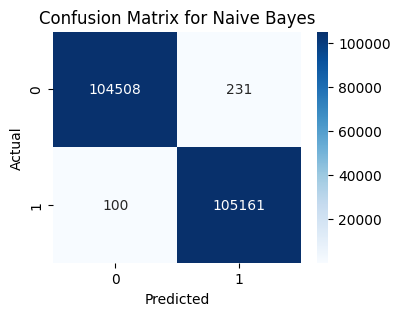

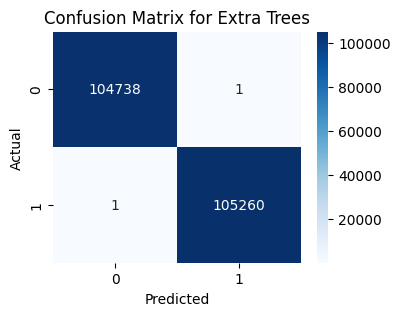

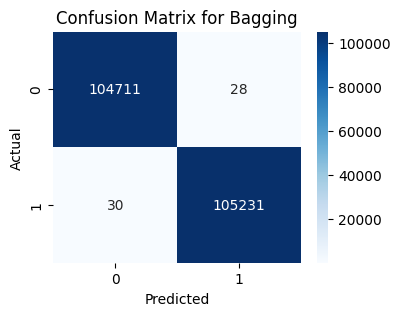

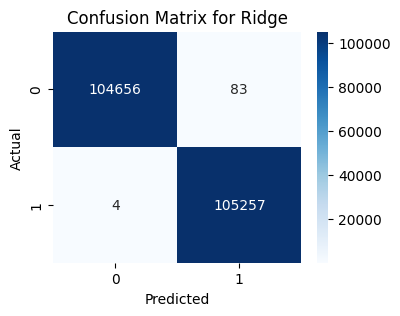

In [ ]:
for name in result:
   plt.figure(figsize=(4, 3))
   sns.heatmap(result[name]['Confusion Matrix'], annot=True, fmt='d', cmap='Blues')
   plt.title(f'Confusion Matrix for {name}')
   plt.xlabel('Predicted')
   plt.ylabel('Actual')
   plt.show()

Comparing Model Accuracies

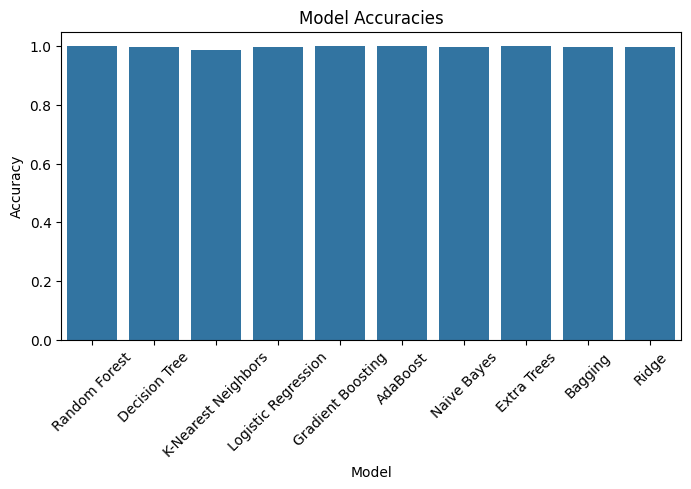

In [ ]:
model_names = list(result.keys())
accuracies = [result[m]['Accuracy Score'] for m in model_names]

plt.figure(figsize=(8, 4))
sns.barplot(x=model_names, y=accuracies)
plt.title('Model Accuracies')
plt.xlabel('Model')
plt.ylabel('Accuracy')
plt.xticks(rotation=45)
plt.show()

Detailed Model Evaluation


In [ ]:
print(f"{'Model':<25}{'Accuracy':<12}{'CV Mean':<12}{'CV Std':<12}")
print("-" * 61)
for name, results in result.items():
    print(f"{name:<25}{results['Accuracy Score']:<12.4f}{results['Cross Validation Score']:<12.4f}{results['Cross Validation STD']:<12.4f}")
print("=" * 61)

for name, results in result.items():
    print(f"\n{'='*60}")
    print(f"Model: {name}")
    print(f"Accuracy: {results['Accuracy Score']:.4f}")
    print(f"Cross-Validation Mean: {results['Cross Validation Score']:.4f}")
    print(f"Cross-Validation Std: {results['Cross Validation STD']:.4f}")
    print("\nClassification Report:")
    print(results['Classification Report'])
    print("Confusion Matrix:")
    print(results['Confusion Matrix'])
    print(f"{'='*60}\n")

Model                    Accuracy    CV Mean     CV Std      
-------------------------------------------------------------
Random Forest            1.0000      1.0000      0.0000      
Decision Tree            0.9995      0.9996      0.0001      
K-Nearest Neighbors      0.9882      0.9883      0.0002      
Logistic Regression      0.9988      0.9988      0.0001      
Gradient Boosting        1.0000      1.0000      0.0000      
AdaBoost                 1.0000      1.0000      0.0000      
Naive Bayes              0.9984      0.9985      0.0001      
Extra Trees              1.0000      1.0000      0.0000      
Bagging                  0.9997      0.9997      0.0000      
Ridge                    0.9996      0.9996      0.0001      

Model: Random Forest
Accuracy: 1.0000
Cross-Validation Mean: 1.0000
Cross-Validation Std: 0.0000

Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00    104739
           1       1.00  

Choosing the best model


In [ ]:
best_model_name = max(result, key=lambda k: result[k]['Accuracy Score'])
best_model = model[best_model_name]
print(f"The best model is: {best_model_name} with an accuracy of {result[best_model_name]['Accuracy Score']:.4f}")

The best model is: Random Forest with an accuracy of 1.0000


Predicting with new data

In [ ]:
new_data = pd.DataFrame({
    'PCI': [70],
    'AADT': [1500],
    'Last Maintenance': [2025],
    'Average Rainfall': [100],
    'Rutting': [5],
    'IRI': [2.5],
    'Road Type': ['Secondary'],
    'Asphalt Type': ['Asphalt']
})
new_data_encoded = preprocessor.transform(new_data)
new_prediction = best_model.predict(new_data_encoded)

if new_prediction[0] == 1:
    print("The pavement needs maintenance.")
else:
    print("The pavement does not need maintenance.")

The pavement does not need maintenance.
